---
jupyter: false
---

# Modeling Engagement with an LSTM

This notebook uses the extracted hand-motion features to train a sequence model.

Each video becomes one time series. Each frame contributes a feature vector, and the model tries to predict the video-level engagement rating from the full sequence.

There are two goals:

- **Prediction:** can the model estimate the engagement rating?
- **Interpretation:** what can we learn by looking at the model weights and gates?


In [1]:
import polars as pl
import LoadVideo as lv
import videofeatures as vf
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display
import random
import copy
random.seed(1)

DBUG_num_frames = None

# Feature configuration
# Base per-frame features already produced by videofeatures.video_extracted_feature_df
BASE_FEATURE_COLS = [
    "moeng_skin",
    "moeng_motion",
    "moeng_combined",
    "Speed",
    "Direction",
]

# Categorical metadata columns (not z-scored)
# Keep task type as a categorical sequence feature.
# Condition is excluded here because it is highly correlated with the label in this tiny pilot dataset.
CATEGORICAL_COLS = ["TaskType"]

# Additional engineered columns that may already exist in the dataframe
EXTRA_FEATURE_COLS: list[str] = []

TARGET_LABEL = "EngagementRating"

# Final feature list
FEATURE_COLS = BASE_FEATURE_COLS + CATEGORICAL_COLS + EXTRA_FEATURE_COLS
print(FEATURE_COLS)
Z_SCORE_COLS = [c for c in FEATURE_COLS if c not in CATEGORICAL_COLS]
N_INPUT_CHANNELS = len(FEATURE_COLS)

['moeng_skin', 'moeng_motion', 'moeng_combined', 'Speed', 'Direction', 'TaskType']


## Load and Configure Data

This section defines which features enter the model. The target label is `EngagementRating`.

The feature columns include motion-energy signals, hand speed, movement direction, and task metadata. Numeric features are later z-scored using the training set only.


### Build Long DataFrames

The extracted feature files are stored separately for each video. Here we combine them into one long dataframe where each row is one frame from one video.

The dataframe keeps the `video_id`, frame-level features, task metadata, and the trial-level engagement rating.


In [2]:

# Build frame-level data tables

def build_singlevideo_dataframe(video_id: str, data_root=None) -> pl.DataFrame:
    df = vf.video_extracted_feature_df(video_id, data_root=data_root).sort(vf.FRAME_INDEX_COL)

    if DBUG_num_frames is not None:
        df = df.filter(pl.col(vf.FRAME_INDEX_COL) <= DBUG_num_frames)

    meta = vf.video_meta_features_df(video_id)
    meta_cols = [col for col in CATEGORICAL_COLS if col in meta.columns]
    for col in meta_cols + [TARGET_LABEL]:
        value = meta.select(col).item(0, 0)
        df = df.with_columns(pl.lit(value).alias(col))

    return df


def build_allvideo_dataframe() -> pl.DataFrame:
    from metadata import VIDEO_ID_COLUMN

    video_ids = lv.list_video_ids()

    df = pl.DataFrame()
    for vid_id in video_ids:
        df_vid = build_singlevideo_dataframe(video_id=vid_id)
        df_vid = df_vid.with_columns(pl.lit(vid_id).alias(VIDEO_ID_COLUMN))
        df = df.vstack(df_vid)

    df = df.select([VIDEO_ID_COLUMN, pl.all().exclude(VIDEO_ID_COLUMN)])
    return df


def compute_zscore_stats(df: pl.DataFrame, cols: list[str]) -> dict[str, dict[str, float]]:
    """Return per-column mean/std for z-score standardization."""
    stats_row = df.select(
        [pl.col(c).mean().alias(f"{c}_mean") for c in cols]
        + [pl.col(c).std(ddof=1).alias(f"{c}_std") for c in cols]
    ).to_dicts()[0]

    return {
        col: {
            "mean": stats_row[f"{col}_mean"],
            "std": stats_row[f"{col}_std"] or 1.0,  # avoid divide-by-zero
        }
        for col in cols
    }


def apply_zscore(df: pl.DataFrame, stats: dict[str, dict[str, float]]) -> pl.DataFrame:
    # standardize columns using precomputed stats
    exprs = [
        ((pl.col(col) - stat["mean"]) / stat["std"]).alias(col)
        for col, stat in stats.items()
    ]
    return df.with_columns(exprs)


df_example = build_singlevideo_dataframe(video_id="vid_000010")
df_example.head()

FrameIndex,x,y,moeng_skin,moeng_motion,moeng_combined,Speed,Direction,TaskType,EngagementRating
i64,i64,i64,f64,f64,f64,f64,f64,str,i32
1,537,477,186405.0,663255.0,412080.0,0.0,0.0,"""B""",3
2,537,477,537540.0,1.116135e6,761430.0,0.0,0.0,"""B""",3
3,538,477,436560.0,863685.0,642345.0,1.0,0.0,"""B""",3
4,537,476,426615.0,893265.0,724455.0,1.414214,-135.0,"""B""",3
5,538,476,596955.0,948345.0,848895.0,1.0,0.0,"""B""",3


### Convert Videos into Sequences

An LSTM expects one sequence per trial. The batching code groups rows by video, converts each video into a tensor with shape `[time, features]`, and pads videos within a mini-batch when needed.

Padding lets us batch sequences even if they do not all have exactly the same number of frames.


In [3]:
# helper: encode categorical columns to numeric (label codes)
def coerce_categoricals(df: pl.DataFrame, categorical_cols: list[str]) -> pl.DataFrame:
    for col in categorical_cols:
        if col in df.columns:
            if df.schema[col] == pl.Utf8:
                df = df.with_columns(pl.col(col).cast(pl.Categorical).to_physical().cast(pl.Float32))
            else:
                df = df.with_columns(pl.col(col).cast(pl.Float32))
    return df


# ##############
# FORMAT DATA

def samples_from_long_df(
    df: pl.DataFrame,
    feature_cols: list[str] | None = None,
    label_col: str = TARGET_LABEL,
) -> list[tuple[torch.Tensor, torch.Tensor]]:
    from metadata import VIDEO_ID_COLUMN

    feature_cols = feature_cols or FEATURE_COLS
    missing = [c for c in feature_cols + [label_col] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in dataframe: {missing}")

    df = coerce_categoricals(df, CATEGORICAL_COLS)
    df = df.sort([VIDEO_ID_COLUMN, vf.FRAME_INDEX_COL])
    video_ids = df.select(VIDEO_ID_COLUMN).unique(maintain_order=True).to_series().to_list()

    samples = []
    for vid in video_ids:
        df_vid = df.filter(pl.col(VIDEO_ID_COLUMN) == vid)

        # x: [Ti, F]
        x_np = df_vid.select(feature_cols).to_numpy()
        x = torch.tensor(x_np, dtype=torch.float32)

        # y: scalar (same for every row in df_vid, so take the first)
        y_val = float(df_vid.select(label_col).item(0, 0))
        y = torch.tensor(y_val, dtype=torch.float32)

        samples.append((x, y))

    return samples


def make_batch(samples):
    xs = [sample[0] for sample in samples]
    ys = [sample[1] for sample in samples]

    lengths = torch.tensor([x.shape[0] for x in xs], dtype=torch.long)  # [B]
    X = pad_sequence(xs, batch_first=True)  # [B, Tmax, F]
    y = torch.stack(ys)  # [B]

    Tmax = X.shape[1]
    mask = torch.arange(Tmax)[None, :] < lengths[:, None]  # [B, Tmax]

    return X, y, lengths, mask


def make_all_batches(samples, batch_size=4, shuffle=True):
    idxs = list(range(len(samples)))
    if shuffle:
        random.shuffle(idxs)

    batches = []
    for start in range(0, len(idxs), batch_size):
        batch_samples = [samples[i] for i in idxs[start:start + batch_size]]
        X, y, lengths, mask = make_batch(batch_samples)
        batches.append((X, y, lengths, mask))

    return batches

## Define the LSTM Model

The model is a small sequence-to-one regressor. It reads a full time series and predicts one number: the engagement rating.

What to notice:

- The LSTM processes the feature sequence one time step at a time.
- We use the final valid hidden state as the model's summary of the video.
- A linear output layer maps that summary to a predicted engagement score.

This is the deep-learning step: the model learns a representation of the movement sequence.


In [4]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, X, lengths):
        out, _ = self.lstm(X)  # out: [B, Tmax, H]

        # gather last valid timestep per sequence (length-1)
        idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, out.size(-1))  # [B,1,H]
        h_last = out.gather(1, idx).squeeze(1)                          # [B,H]

        y_hat = self.head(h_last).squeeze(-1)                           # [B]
        return y_hat

## Train the Model

The training loop is intentionally direct so the main steps are visible.

Each epoch:

1. Make mini-batches of padded video sequences.
2. Predict engagement ratings.
3. Compute mean squared error.
4. Backpropagate and update model weights.
5. Track training loss, validation loss, and selected model weights.

We save extra information during training because this chapter is not only about prediction. Later, we inspect the output-layer weights and LSTM input-gate weights as simple interpretation tools.


In [5]:
def train(samples, input_size, hidden_size=64, num_layers=2, epochs=50, batch_size=2, lr=1e-3, device="cpu", val_samples=None):
    model = LSTMRegressor(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    head_param_hist = []
    input_gate_hist = []
    train_loss_hist = []
    val_loss_hist = []

    best_state = None
    best_epoch = None
    best_val = float("inf")

    for epoch in range(1, epochs + 1):
        model.train()
        batches = make_all_batches(samples, batch_size=batch_size, shuffle=True)

        total = 0.0
        for X, y, lengths, mask in batches:
            X = X.to(device)
            y = y.to(device)
            lengths = lengths.to(device)

            y_hat = model(X, lengths)
            loss = loss_fn(y_hat, y)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total += float(loss.item())

        # live plot + store head params (weight + bias) once per epoch
        w_head = model.head.weight.detach().cpu().numpy().reshape(-1)
        b_head = model.head.bias.detach().cpu().numpy().reshape(-1)
        head_params = np.concatenate([w_head, b_head])
        head_param_hist.append(head_params)

        # store input-gate weights per feature (mean over hidden units)
        W_ih = model.lstm.weight_ih_l0
        H = model.lstm.hidden_size
        input_gate_w = W_ih[:H, :]
        input_gate_feat = input_gate_w.mean(dim=0).detach().cpu().numpy()
        input_gate_hist.append(input_gate_feat)

        avg_loss = total / max(1, len(batches))
        train_loss_hist.append(avg_loss)

        val_avg = None
        is_best_epoch = False
        if val_samples:
            model.eval()
            val_batches = make_all_batches(val_samples, batch_size=batch_size, shuffle=False)
            val_total = 0.0
            with torch.no_grad():
                for X, y, lengths, mask in val_batches:
                    X = X.to(device)
                    y = y.to(device)
                    lengths = lengths.to(device)
                    y_hat = model(X, lengths)
                    val_total += float(loss_fn(y_hat, y).item())
            val_avg = val_total / max(1, len(val_batches))
            val_loss_hist.append(val_avg)
        if val_avg is not None:
            is_best_epoch = val_avg < best_val
            if is_best_epoch:
                best_val = val_avg
                best_epoch = epoch
                best_state = copy.deepcopy(model.state_dict())

        if val_avg is None:
            print(f"epoch {epoch:03d} | train {avg_loss:.4f}")
        else:
            print(f"epoch {epoch:03d} | train {avg_loss:.4f} | val {val_avg:.4f} | best epoch? {is_best_epoch}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, head_param_hist, input_gate_hist, train_loss_hist, val_loss_hist, best_epoch


## Run Training: Train/Validation Split

We split videos into training and validation sets so we can ask whether the model generalizes to held-out trials.

This pilot dataset is very small, so the split is intentionally simple: **50% train and 50% validation**. The model is trained for a fixed number of epochs, but the final checkpoint is restored from the epoch with the lowest validation loss.

Because there is only one participant and 24 videos, these results should be treated as a demonstration of the workflow, not as a strong estimate of real-world performance.


In [6]:
N_EPOCHS = 150
NUM_HID_UNITS = 128
BATCH_SIZE = 4
RAND_SEED = 42
N_LSTM_LAYERS = 2
TRAIN_FRACTION = 0.5
from metadata import VIDEO_ID_COLUMN


df_all = build_allvideo_dataframe()
video_ids = df_all.select(VIDEO_ID_COLUMN).unique(maintain_order=True).to_series().to_list()


random.seed(RAND_SEED)
rng = np.random.default_rng(RAND_SEED)
idx = rng.permutation(len(video_ids))
split = int(TRAIN_FRACTION * len(video_ids))
train_video_ids = [video_ids[i] for i in idx[:split]]
val_video_ids = [video_ids[i] for i in idx[split:]]

print(f"N_TRAIN_VIDS:", len(train_video_ids))
print(f"N_VAL_VIDS:", len(val_video_ids))

df_train = df_all.filter(pl.col(VIDEO_ID_COLUMN).is_in(train_video_ids))
df_val = df_all.filter(pl.col(VIDEO_ID_COLUMN).is_in(val_video_ids))

zscore_stats = compute_zscore_stats(df_train, Z_SCORE_COLS)
df_train = apply_zscore(df_train, zscore_stats)
df_val = apply_zscore(df_val, zscore_stats)

train_samples = samples_from_long_df(df_train)
val_samples = samples_from_long_df(df_val)
model, head_param_hist, input_gate_hist, train_loss_hist, val_loss_hist, best_epoch = train(
    train_samples,
    input_size=N_INPUT_CHANNELS,
    hidden_size=NUM_HID_UNITS,
    num_layers=N_LSTM_LAYERS,
    epochs=N_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=1e-3,
    val_samples=val_samples,
)

# stack head params for plotting
if head_param_hist:
    W = np.vstack(head_param_hist)  # [epochs, n_params]
else:
    W = np.zeros((1, NUM_HID_UNITS + 1))

N_TRAIN_VIDS: 13
N_VAL_VIDS: 14
epoch 001 | train 6.3590 | val 12.7816 | best epoch? True
epoch 002 | train 7.8422 | val 10.7956 | best epoch? True
epoch 003 | train 3.9728 | val 5.6797 | best epoch? True
epoch 004 | train 1.8656 | val 2.4468 | best epoch? True
epoch 005 | train 1.5682 | val 2.5872 | best epoch? False
epoch 006 | train 1.1835 | val 3.4018 | best epoch? False
epoch 007 | train 1.2292 | val 3.7535 | best epoch? False
epoch 008 | train 1.2362 | val 3.8187 | best epoch? False
epoch 009 | train 1.1312 | val 3.6626 | best epoch? False
epoch 010 | train 1.2442 | val 3.2730 | best epoch? False
epoch 011 | train 0.9634 | val 3.0392 | best epoch? False
epoch 012 | train 1.1879 | val 2.8117 | best epoch? False
epoch 013 | train 1.0448 | val 2.9079 | best epoch? False
epoch 014 | train 0.8376 | val 3.0203 | best epoch? False
epoch 015 | train 0.7927 | val 2.6614 | best epoch? False
epoch 016 | train 0.9759 | val 2.7059 | best epoch? False
epoch 017 | train 1.1353 | val 3.6894 | be

## Evaluate the Model

After training, we evaluate the restored best-validation checkpoint. The goal is to compare predicted engagement ratings with the observed ratings.


### Loss Curves

This line plot shows mean squared error over training.

How to read it:

- Training loss shows how well the model fits the training videos.
- Validation loss shows performance on held-out videos.
- If training loss keeps falling but validation loss rises, the model may be overfitting.

The validation curve selects `best_epoch`; the model is restored to that checkpoint for the remaining analyses.


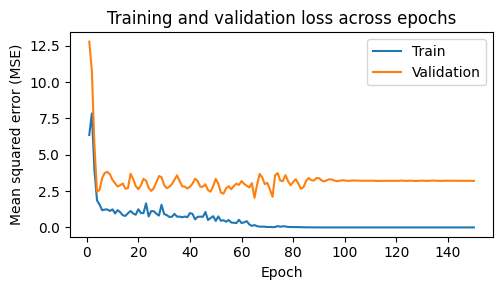

In [7]:
fig_loss, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(range(1, len(train_loss_hist) + 1), train_loss_hist, label="Train")
if val_loss_hist:
    ax.plot(range(1, len(val_loss_hist) + 1), val_loss_hist, label="Validation")
ax.set_title("Training and validation loss across epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean squared error (MSE)")
ax.legend()
plt.tight_layout()
plt.show()

### Metrics and Predictions

We report numeric metrics and a predicted-versus-observed scatter plot.

Metrics:

- **MSE:** average squared prediction error.
- **MAE:** average absolute prediction error.
- **R^2:** fraction of variance explained relative to a mean-only baseline.

Each point in the scatter plot is one video. Points near the diagonal are better predictions.


best validation epoch: 65 (val MSE=2.0389)
train: mse=0.1249 | mae=0.2991 | r2=0.906
val:   mse=2.2130 | mae=1.2532 | r2=0.075


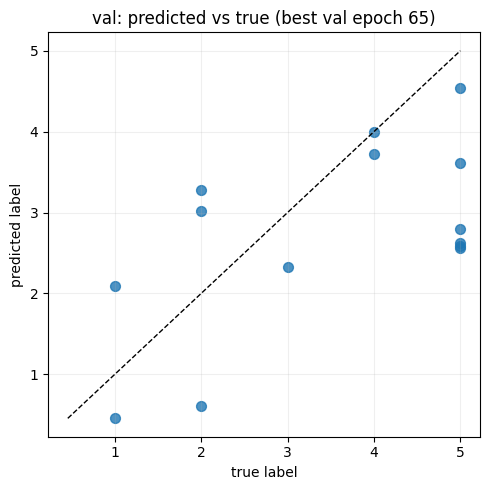

In [8]:
def eval_model(model, samples, batch_size, device="cpu"):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for X, y, lengths, mask in make_all_batches(samples, batch_size=batch_size, shuffle=False):
            X = X.to(device)
            y = y.to(device)
            lengths = lengths.to(device)
            y_hat = model(X, lengths)
            preds.extend(y_hat.detach().cpu().numpy().tolist())
            trues.extend(y.detach().cpu().numpy().tolist())
    preds = np.asarray(preds)
    trues = np.asarray(trues)
    mse = np.mean((preds - trues) ** 2) if len(trues) else np.nan
    mae = np.mean(np.abs(preds - trues)) if len(trues) else np.nan
    denom = np.sum((trues - trues.mean()) ** 2) if len(trues) > 1 else 0.0
    r2 = 1.0 - np.sum((preds - trues) ** 2) / denom if denom > 0 else np.nan
    return trues, preds, mse, mae, r2

# evaluate on train/val
train_true, train_pred, train_mse, train_mae, train_r2 = eval_model(model, train_samples, batch_size=BATCH_SIZE)
val_true, val_pred, val_mse, val_mae, val_r2 = eval_model(model, val_samples, batch_size=BATCH_SIZE)

if best_epoch is not None and val_loss_hist:
    best_val = val_loss_hist[best_epoch - 1]
    print(f"best validation epoch: {best_epoch} (val MSE={best_val:.4f})")
else:
    print("best validation epoch not tracked (no validation set)")

print(f"train: mse={train_mse:.4f} | mae={train_mae:.4f} | r2={train_r2:.3f}")
print(f"val:   mse={val_mse:.4f} | mae={val_mae:.4f} | r2={val_r2:.3f}")

# predicted vs true (val)
plt.figure(figsize=(5, 5))
plt.scatter(val_true, val_pred, s=50, alpha=0.8)
if len(val_true):
    lo = float(min(val_true.min(), val_pred.min()))
    hi = float(max(val_true.max(), val_pred.max()))
    plt.plot([lo, hi], [lo, hi], "k--", linewidth=1)
title_suffix = f"best val epoch {best_epoch}" if best_epoch is not None else "final checkpoint"
plt.title(f"val: predicted vs true ({title_suffix})")
plt.xlabel("true label")
plt.ylabel("predicted label")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## Feature-Level Analysis

The LSTM uses the full time series, which can make it hard to interpret directly. As a simpler comparison, this section aggregates each video into average feature values and fits small linear models.

This is not a replacement for the LSTM. It is a sanity check: do any simple video-level features show an obvious relationship with engagement?


In [9]:
# Linear models on per-video averages for a simple interpretability check
import polars as pl
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from metadata import VIDEO_ID_COLUMN

# 1) Aggregate per video: mean numeric, first categorical, mean target
_df = build_allvideo_dataframe().drop_nulls()
num_cols = [c for c in FEATURE_COLS if c not in CATEGORICAL_COLS]
cat_cols = [c for c in FEATURE_COLS if c in CATEGORICAL_COLS]
df_video = (
    _df
    .group_by(VIDEO_ID_COLUMN)
    .agg(
        [pl.col(c).mean().alias(c) for c in num_cols]
        + [pl.col(c).first().alias(c) for c in cat_cols]
        + [pl.col(TARGET_LABEL).mean().alias(TARGET_LABEL)]
    )
    .to_pandas()
)

# 2) Drop video_id from predictors and one-hot string cols (drop_first for contrast)
df_video = df_video.drop(columns=[VIDEO_ID_COLUMN])
str_cols = [c for c in df_video.columns if df_video[c].dtype == object and c != TARGET_LABEL]
df_video = pd.get_dummies(df_video, columns=str_cols, drop_first=True)
# Coerce to numeric where possible and drop empty columns.
df_video = df_video.apply(pd.to_numeric, errors="coerce")
df_video = df_video.dropna(axis=1, how="all")

# 3) Define feature sets (names containing "interaction" will add all pairwise products)
feature_sets = {
    'all_features': FEATURE_COLS,
    'all_with_interactions': FEATURE_COLS,
    'motion_only': ['moeng_skin', 'moeng_motion', 'moeng_combined'],
    'speed_direction': ['Speed', 'Direction'],
    'speed_dir_task_with_interactions': ['Speed', 'Direction','TaskType'],    
    'speed_dir_task_moeng_with_interactions': ['Speed','TaskType','moeng_skin','moeng_motion'],   
    'speed_dir_task_meskin_with_interactions': ['Speed', 'Direction','TaskType','moeng_skin'], 
    # 'moeng_combined_only': ['moeng_combined'],
    'taskType_only': ['TaskType'],

}

results = []
for name, base_cols in feature_sets.items():
    cols = []
    for b in base_cols:
        cols.extend([c for c in df_video.columns if c == b or c.startswith(f"{b}_")])
    if not cols:
        print(f"Skipping {name}: no matching columns after dummies")
        continue

    X = df_video[cols].copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.dropna(axis=1, how="all")

    if 'interaction' in name:
        cont_cols = [c for c in cols if df_video[c].nunique() > 2]
        for i in range(len(cont_cols)):
            for j in range(i + 1, len(cont_cols)):
                inter_name = f"{cont_cols[i]}*{cont_cols[j]}"
                X[inter_name] = X[cont_cols[i]] * X[cont_cols[j]]

    # standardize non-binary numeric columns
    for col in X.columns:
        series = X[col]
        if pd.api.types.is_numeric_dtype(series) and series.nunique() > 2:
            s = series.std()
            if s != 0:
                X[col] = (series - series.mean()) / s

    y = pd.to_numeric(df_video[TARGET_LABEL], errors="coerce")
    mask = ~(X.isna().any(axis=1) | y.isna())
    X = X.loc[mask]
    y = y.loc[mask]
    X = X.astype(float)
    y = y.astype(float)
    try:
        model = sm.OLS(y, sm.add_constant(X)).fit()
    except Exception as e:
        print(f"Skipping {name}: model fit failed ({e})")
        continue

    results.append({
        'name': name,
        'features': list(X.columns),
        'r2': model.rsquared,
        'aic': model.aic,
        'bic': model.bic,
        'X': X,
        'model': model,
    })

if not results:
    raise ValueError('No models were fit (check feature sets / data).')


results = sorted(results, key=lambda r: r['r2'], reverse=True)
print(f"\nvideo-level rows: {len(df_video)}\n")
for r in results:
    print(f"{r['name']:32s} | R2={r['r2']:.3f} | AIC={r['aic']:.1f} | BIC={r['bic']:.1f} | k={len(r['features'])}")


Skipping taskType_only: no matching columns after dummies

video-level rows: 27

all_with_interactions            | R2=0.423 | AIC=114.4 | BIC=135.2 | k=15
all_features                     | R2=0.229 | AIC=102.3 | BIC=110.0 | k=5
motion_only                      | R2=0.226 | AIC=98.4 | BIC=103.5 | k=3
speed_dir_task_moeng_with_interactions | R2=0.186 | AIC=105.7 | BIC=114.8 | k=6
speed_dir_task_meskin_with_interactions | R2=0.082 | AIC=109.0 | BIC=118.0 | k=6
speed_dir_task_with_interactions | R2=0.011 | AIC=105.0 | BIC=110.1 | k=3
speed_direction                  | R2=0.010 | AIC=103.0 | BIC=106.9 | k=2


In [10]:

# Use the lowest-BIC model as a conservative summary model for this tiny dataset.
best = min(results, key=lambda r: r['bic'])
best_X = best['X']
best_model = best['model']
print(f"\nSummary model: {best['name']} (BIC={best['bic']:.1f})")
print(best_model.summary())

# corr = best_X.corr()
# print("\nPredictor correlation matrix (top model):")
# print(corr)

X_vif = sm.add_constant(best_X)
vif = [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])]
print("VIF (top model predictors):")
for name, val in zip(best_X.columns, vif):
    print(f"{name:25s}: {val:6.3f}")


Summary model: motion_only (BIC=103.5)
                            OLS Regression Results                            
Dep. Variable:       EngagementRating   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     2.233
Date:                Sat, 09 May 2026   Prob (F-statistic):              0.111
Time:                        22:32:14   Log-Likelihood:                -45.182
No. Observations:                  27   AIC:                             98.36
Df Residuals:                      23   BIC:                             103.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
cons

### Output-Layer Weights

This heatmap shows how the final linear layer changes during training.

How to read it:

- **x-axis:** output-layer parameters.
- **y-axis:** epoch.
- **color:** parameter value.

These weights are not a full explanation of the model, but they help show that the readout layer is being updated during learning.


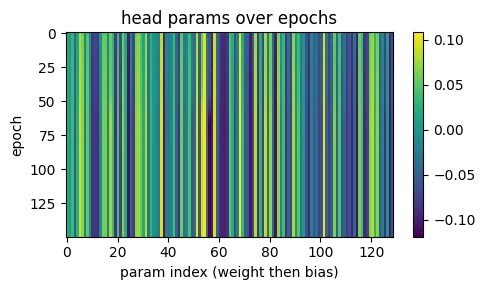

In [11]:
fig_head, ax = plt.subplots(1, 1, figsize=(5, 3))
im = ax.imshow(W, aspect="auto", interpolation="nearest")
ax.set_title("head params over epochs")
ax.set_xlabel("param index (weight then bias)")
ax.set_ylabel("epoch")
fig_head.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### LSTM Input-Gate Weights

This heatmap tracks the average input-gate weights for each feature during training.

How to read it:

- **x-axis:** input feature.
- **y-axis:** epoch.
- **color:** average input-gate weight across hidden units.

This is an interpretation-oriented plot. It gives a rough view of how strongly each input feature is involved in the LSTM's gating mechanism.


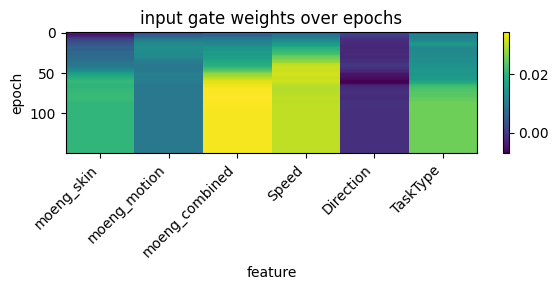

In [12]:

# input gate weights over epochs (mean over hidden units)
feature_names = FEATURE_COLS
if input_gate_hist:
    G = np.vstack(input_gate_hist)  # [epochs, n_features]
else:
    G = np.zeros((1, len(feature_names)))

plt.figure(figsize=(6, 3))
plt.imshow(G, aspect="auto", interpolation="nearest")
plt.title("input gate weights over epochs")
plt.xlabel("feature")
plt.ylabel("epoch")
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha="right")
plt.colorbar()
plt.tight_layout()
plt.show()

## Takeaway

This notebook completes the pipeline of turning extracted movement features into a supervised learning problem. The LSTM gives one way to model the full time series, while the loss curves, prediction plot, linear feature checks, and gate-weight visualizations help us interpret what the model may be learning.